## ECE 2112: Advanced Computer Programming and Algorithms

# EXPERIMENT 4: DATA WRANGLING AND DATA VISUALIZATION

**Name:** Rapis, Reese Cassandra T. <br> **Section:** 2ECE-C <br> **Date Submitted:** September 12, 2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## A. VISAYAS COMMUNICATION DATAFRAME

Filter students from Visayas under the Communication track using two explicit Boolean conditions, then keep only the required columns.

In [3]:
# Load the ECE Board Exam dataset
df = pd.read_excel("board2.xlsx")

# Derive the Average column from raw subject scores
df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

# Filter raw data using two conditions, then keep only relevant columns
VisComm = df.loc[(df['Hometown']=='Visayas') & (df['Track']=='Communication'), ['Name', 'Gender', 'Math', 'Electronics', 'Average']]

print("VisComm:\n", VisComm)
print("\nNumber of rows:", VisComm.shape[0])

VisComm:
    Name  Gender  Math  Electronics  Average
10  S11  Female    48           56    54.75
11  S12    Male    89           67    76.00
17  S18    Male    81           40    63.50
21  S22  Female    64           39    62.50
27  S28    Male    85           53    67.75

Number of rows: 5


## B. VISAYAS FEMALE DATAFRAME

Filter students from Visayas who are Female, then filter again for an Average of at least 60 without modifying the original filtered DataFrame

In [4]:
# Filter raw data using two conditions, then keep only the relevant columns
VisFemale = df.loc[(df['Hometown']=='Visayas') & (df['Gender']=='Female'), ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

print("VisFemale:\n", VisFemale)

# Further filter without modifying VisFemale itself
print("\nVisFemale with Average >= 60:\n", VisFemale[VisFemale['Average'] >= 60])

VisFemale:
    Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
10  S11     Communication    48           56    54.75
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
23  S24  Microelectronics    60           45    57.75
25  S26   Instrumentation    83           47    65.75

VisFemale with Average >= 60:
    Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
25  S26   Instrumentation    83           47    65.75


## C. CATEGORY-AVERAGE VISUALIZATION

Compute and display the mean Average per category for Track, Gender, and Hometown, then visualize each summary as a bar chart using Matplotlib, and identify the top-performing category for each feature.

Mean Average by Track:
 Track
Communication       67.975
Instrumentation     65.225
Microelectronics    67.500
Name: Average, dtype: float64

Mean Average by Gender:
 Gender
Female    66.616667
Male      67.183333
Name: Average, dtype: float64

Mean Average by Hometown:
 Hometown
Luzon       68.083333
Mindanao    66.678571
Visayas     65.750000
Name: Average, dtype: float64


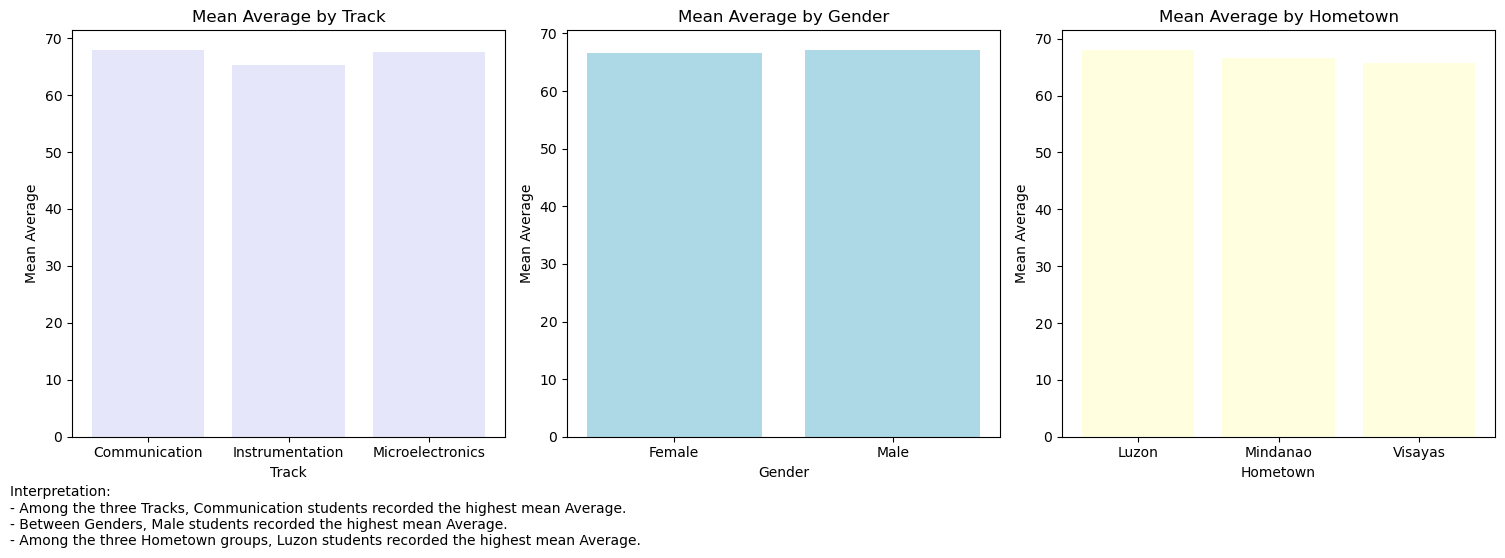

In [44]:
# a. For each feature, compute the mean of Average for every category using Pandas
track_means = df.groupby('Track')['Average'].mean()
gender_means = df.groupby('Gender')['Average'].mean()
hometown_means = df.groupby('Hometown')['Average'].mean()

# b. Display the three summary tables
print("Mean Average by Track:\n", track_means)
print("\nMean Average by Gender:\n", gender_means)
print("\nMean Average by Hometown:\n", hometown_means)

# c.  Create one figure containing three bar charts: mean Average by Track, by Gender, and by Hometown.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(track_means.index, track_means.values, color='lavender')
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average')

axes[1].bar(gender_means.index, gender_means.values, color='lightblue')
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Mean Average')

axes[2].bar(hometown_means.index, hometown_means.values, color='lightyellow')
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')
axes[2].set_ylabel('Mean Average')

plt.tight_layout()

fig.text(0, -0.1, 'Interpretation: \n- Among the three Tracks, Communication students recorded the highest mean Average.\n- Between Genders, Male students recorded the highest mean Average.\n- Among the three Hometown groups, Luzon students recorded the highest mean Average.', style='normal')
plt.show()